# Session 9: Support Vector Machines — Wine Dataset

## Setup
Import libraries used throughout the notebook.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score, classification_report)

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


---
## Q1. What is a Support Vector Machine?
What is a Support Vector Machine (SVM), and what problem is it solving? Explain the concepts of the maximum-margin hyperplane and support vectors. Why does maximizing the margin between classes tend to produce a classifier that generalizes well to unseen data, compared to any hyperplane that merely separates the training points?


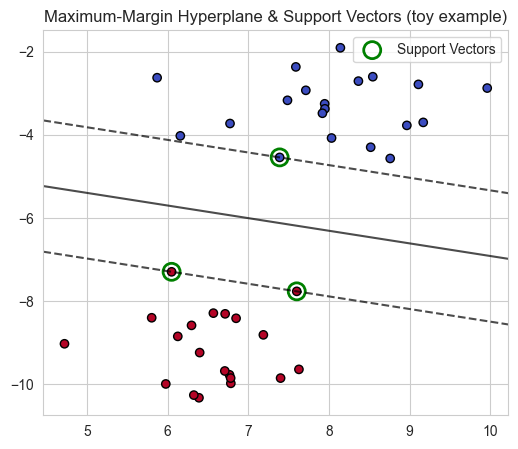

In [11]:
# Illustrate the maximum-margin idea with a small synthetic 2D example
from sklearn.datasets import make_blobs

X_demo, y_demo = make_blobs(n_samples=40, centers=2, cluster_std=0.8, random_state=6)

demo_svm = SVC(kernel='linear', C=1000)  # large C -> hard margin, easy to see
demo_svm.fit(X_demo, y_demo)

plt.figure(figsize=(6, 5))
plt.scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo, cmap='coolwarm', edgecolors='k')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = demo_svm.decision_function(xy).reshape(XX.shape)


ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.7,
           linestyles=['--', '-', '--'])
ax.scatter(demo_svm.support_vectors_[:, 0], demo_svm.support_vectors_[:, 1],
           s=150, facecolors='none', edgecolors='green', linewidths=2, label='Support Vectors')
plt.title("Maximum-Margin Hyperplane & Support Vectors (toy example)")
plt.legend()
plt.show()


---
## Q2. Load and Explore the Wine Dataset
Load and explore the Wine dataset. Report the shape of the data, the list of feature names, and the class balance of the target (counts and percentages). Given that SVM was originally formulated as a binary classifier, briefly explain how it is extended to handle more than two classes (one-vs-rest or one-vs-one).


Shape of X: (178, 13)

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target classes: {0: np.str_('class_0'), 1: np.str_('class_1'), 2: np.str_('class_2')}

Class balance (counts):
target
1    71
0    59
2    48
Name: count, dtype: int64

Class balance (percentages):
target
1    39.89
0    33.15
2    26.97
Name: proportion, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13456\3740632675.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


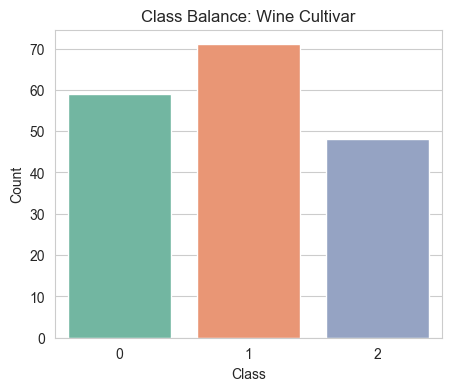

In [12]:
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Shape of X:", X.shape)
print("\nFeature names:")
print(list(data.feature_names))
print("\nTarget classes:", dict(enumerate(data.target_names)))

print("\nClass balance (counts):")
print(y.value_counts())
print("\nClass balance (percentages):")
print((y.value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x=y, palette='Set2')
plt.title("Class Balance: Wine Cultivar")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


---
## Q3. Train/Test Split and Feature Scaling
Split the data into training (80%) and test (20%) sets using `train_test_split` with `random_state=42` and `stratify=y`. Scale the features using `StandardScaler`, fitting it on the training data only. Why is feature scaling especially important for SVMs (more so than for a model like decision trees)? What could go wrong if one feature were left on a much larger numeric scale than the others?


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTraining class balance:\n", y_train.value_counts(normalize=True).round(3))

# Show how wildly different the raw feature scales are (motivates scaling)
print("\nRaw feature ranges (min - max) for a few columns:")
print(X_train[['alcohol', 'magnesium', 'proline']].describe().loc[['min', 'max']])

# Fit the scaler ONLY on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nAfter scaling, mean~0 / std~1 for every feature (train set):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[['mean', 'std']].round(2))


Train shape: (142, 13)  Test shape: (36, 13)

Training class balance:
 target
1    0.401
0    0.331
2    0.268
Name: proportion, dtype: float64

Raw feature ranges (min - max) for a few columns:
     alcohol  magnesium  proline
min    11.03       70.0    278.0
max    14.83      162.0   1515.0

After scaling, mean~0 / std~1 for every feature (train set):
      alcohol  malic_acid  ash  alcalinity_of_ash  magnesium  total_phenols  \
mean      0.0        -0.0  0.0                0.0        0.0           -0.0   
std       1.0         1.0  1.0                1.0        1.0            1.0   

      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  hue  \
mean         0.0                  -0.0             -0.0              0.0 -0.0   
std          1.0                   1.0              1.0              1.0  1.0   

      od280/od315_of_diluted_wines  proline  
mean                           0.0     -0.0  
std                            1.0      1.0  


---
## Q4. Fit a Linear-Kernel SVM
Fit a linear-kernel SVM (`SVC(kernel='linear')`) on the scaled training data. Report how many support vectors were selected (`model.n_support_`) and what fraction of the training set they represent. What does it mean, geometrically, that only a subset of the training points becomes support vectors while the rest have no influence on the decision boundary?


In [ ]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

n_support = svm_linear.n_support_
total_support = n_support.sum()
fraction = total_support / len(X_train)

print("Support vectors per class (class_0, class_1, class_2):", n_support)
print("Total support vectors:", total_support)
print("Training set size:", len(X_train))
print(f"Fraction of training set used as support vectors: {fraction:.2%}")


Support vectors per class (class_0, class_1, class_2): [ 4 11 12]
Total support vectors: 27
Training set size: 142
Fraction of training set used as support vectors: 19.01%


---
## Q5. Predictions, Confusion Matrix, and Metrics
Generate predictions on the test set, build the confusion matrix, and compute accuracy, precision, recall, and F1-score (using macro-averaging, since this is a 3-class problem). Which class, if any, is hardest for the model to distinguish? Support your answer with numbers from the confusion matrix.


Confusion Matrix (rows=actual, cols=predicted):
[[12  0  0]
 [ 1 13  0]
 [ 0  1  9]]


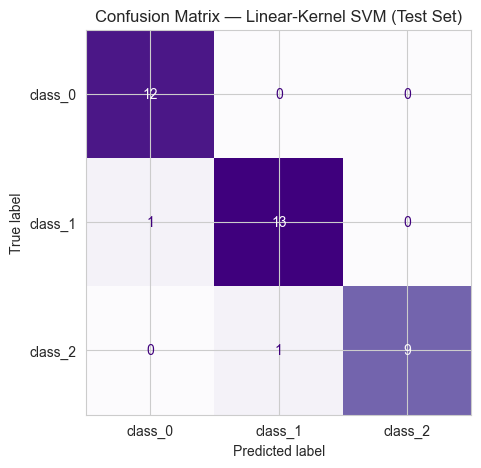


Accuracy:           0.9444
Precision (macro):  0.9505
Recall (macro):     0.9429
F1-score (macro):   0.9453

Full classification report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [15]:
y_pred = svm_linear.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, cmap='Purples', colorbar=False)
plt.title("Confusion Matrix — Linear-Kernel SVM (Test Set)")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"\nAccuracy:           {accuracy:.4f}")
print(f"Precision (macro):  {precision_macro:.4f}")
print(f"Recall (macro):     {recall_macro:.4f}")
print(f"F1-score (macro):   {f1_macro:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


---
## Q6. The Kernel Trick and the C Hyperparameter
Explain what the 'kernel trick' allows an SVM to do that a plain linear decision boundary cannot, and describe in plain terms what the linear, polynomial, and RBF (Gaussian) kernels each do. Separately, explain the role of the regularization parameter C: what happens to the margin and to training error as C is increased vs. decreased?


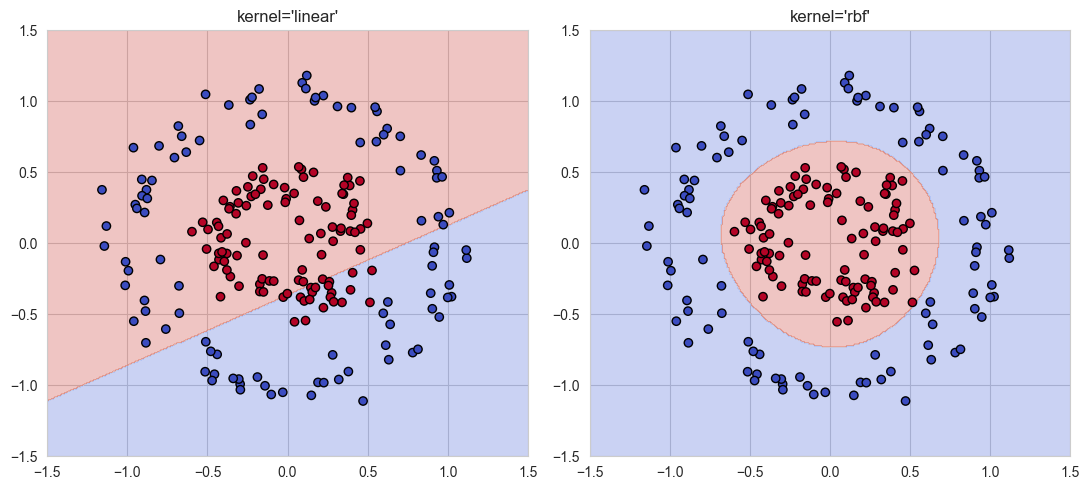

In [16]:
# Illustrate: a linearly-inseparable 2D dataset that only a non-linear kernel can separate well
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(n_samples=200, factor=0.4, noise=0.1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, kernel in zip(axes, ['linear', 'rbf']):
    clf = SVC(kernel=kernel, C=1, gamma='scale').fit(X_circ, y_circ)
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap='coolwarm', edgecolors='k')
    ax.set_title(f"kernel='{kernel}'")

plt.tight_layout()
plt.show()


---
## Q7. Compare Kernels with GridSearchCV
Using 5-fold cross-validation on the training set, tune `C` for a linear kernel and tune both `C` and `gamma` for an RBF kernel (`SVC(kernel='rbf')`). Report the best parameters and best cross-validation accuracy for each kernel, then evaluate both final models on the held-out test set in a comparison table. Which kernel would you recommend for this dataset, and why?


In [17]:
# --- Linear kernel: tune C ---
param_grid_linear = {'C': [0.01, 0.1, 1, 10, 100]}
gs_linear = GridSearchCV(SVC(kernel='linear', random_state=42), param_grid_linear,
                          cv=5, scoring='accuracy')
gs_linear.fit(X_train_scaled, y_train)

print("Linear kernel — best params:", gs_linear.best_params_)
print(f"Linear kernel — best CV accuracy: {gs_linear.best_score_:.4f}")

# --- RBF kernel: tune C and gamma ---
param_grid_rbf = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1]}
gs_rbf = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid_rbf,
                       cv=5, scoring='accuracy')
gs_rbf.fit(X_train_scaled, y_train)

print("\nRBF kernel — best params:", gs_rbf.best_params_)
print(f"RBF kernel — best CV accuracy: {gs_rbf.best_score_:.4f}")

# --- Evaluate both tuned models on the held-out test set ---
best_linear = gs_linear.best_estimator_
best_rbf = gs_rbf.best_estimator_

pred_linear_test = best_linear.predict(X_test_scaled)
pred_rbf_test = best_rbf.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Kernel': ['Linear', 'RBF'],
    'Best Params': [gs_linear.best_params_, gs_rbf.best_params_],
    'CV Accuracy (train)': [gs_linear.best_score_, gs_rbf.best_score_],
    'Test Accuracy': [accuracy_score(y_test, pred_linear_test), accuracy_score(y_test, pred_rbf_test)],
    'Test F1 (macro)': [f1_score(y_test, pred_linear_test, average='macro'),
                         f1_score(y_test, pred_rbf_test, average='macro')]
})
comparison


Linear kernel — best params: {'C': 0.01}
Linear kernel — best CV accuracy: 0.9862

RBF kernel — best params: {'C': 1, 'gamma': 0.1}
RBF kernel — best CV accuracy: 0.9862


,Kernel,Best Params,CV Accuracy (train),Test Accuracy,Test F1 (macro)
0,Linear,{'C': 0.01},0.986207,1.000000,1.000000
1,RBF,"{'C': 1, 'gamma': 0.1}",0.986207,0.972222,0.970962


---
## Q8. Visualize the Decision Boundary
Using only two features (`alcohol` and `color_intensity`), plot the decision regions produced by a linear-kernel SVM side by side with an RBF-kernel SVM. What does the shape of each boundary reveal about the flexibility of the two kernels, and what is the risk of choosing a kernel that is too flexible for the amount of training data available?


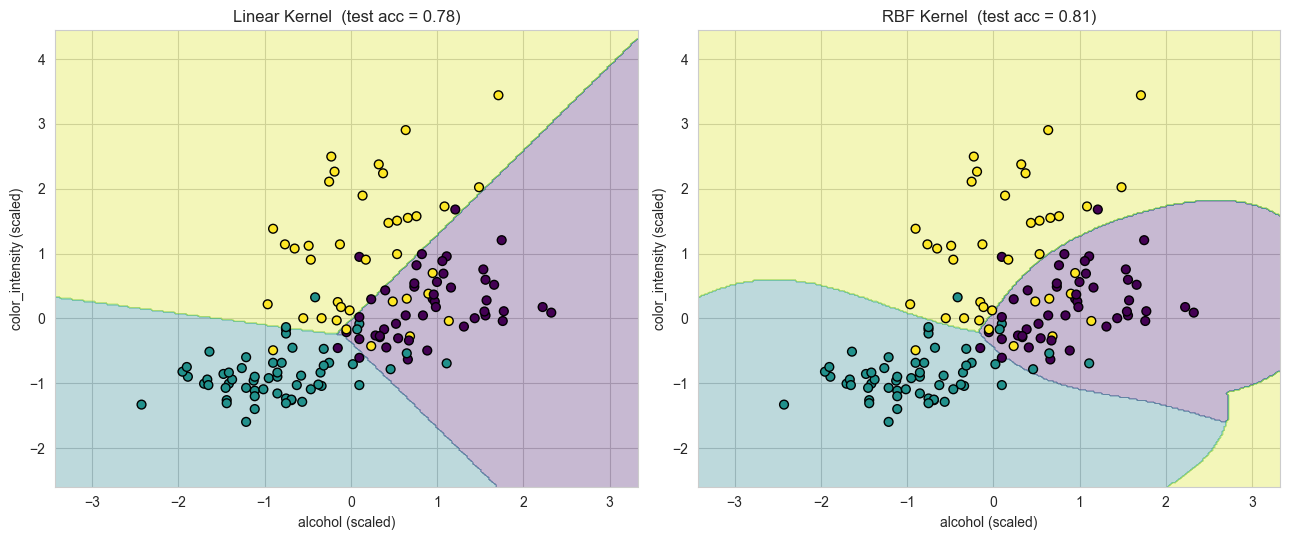

In [18]:
# Use only 2 features so the boundary can be visualized in 2D
feat_x, feat_y = 'alcohol', 'color_intensity'
X_2d = X[[feat_x, feat_y]].values

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

scaler_2d = StandardScaler()
X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

svm_linear_2d = SVC(kernel='linear', C=1).fit(X_2d_train_scaled, y_2d_train)
svm_rbf_2d = SVC(kernel='rbf', C=1, gamma='scale').fit(X_2d_train_scaled, y_2d_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

x_min, x_max = X_2d_train_scaled[:, 0].min() - 1, X_2d_train_scaled[:, 0].max() + 1
y_min, y_max = X_2d_train_scaled[:, 1].min() - 1, X_2d_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for ax, clf, title in zip(axes, [svm_linear_2d, svm_rbf_2d], ['Linear Kernel', 'RBF Kernel']):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_2d_train_scaled[:, 0], X_2d_train_scaled[:, 1], c=y_2d_train,
               cmap='viridis', edgecolors='k', s=40)
    ax.set_xlabel(f"{feat_x} (scaled)")
    ax.set_ylabel(f"{feat_y} (scaled)")
    test_acc = accuracy_score(y_2d_test, clf.predict(X_2d_test_scaled))
    ax.set_title(f"{title}  (test acc = {test_acc:.2f})")

plt.tight_layout()
plt.show()


In [3]:
ch='z'
print(ch-'a')

TypeError: unsupported operand type(s) for -: 'str' and 'str'